In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.special import expit

In [41]:
np.random.seed(2025)

n = 1000
x = np.random.normal(5, 2, n)
y = 2 + 2 * x**2 + np.random.normal(0, 1, n)
pr = expit(5 - 1 * x)  # plogis(5 - 1*x)
R = np.random.binomial(1, pr, n)
y_miss = np.where(R == 1, y, np.nan)

sim_data = pd.DataFrame({
    'x': x,
    'y': y,
    'R': R,
    'y1': y_miss.copy(),
    'y2': y_miss.copy(),
    'y3': y_miss.copy()
})

sim_data['is_missing'] = sim_data['y1'].isna()
sim_data.head()

,x,y,R,y1,y2,y3,is_missing
0,4.815220,49.206337,1,49.206337,49.206337,49.206337,False
1,6.468571,86.598564,0,NaN,NaN,NaN,True
2,2.122236,11.117561,1,11.117561,11.117561,11.117561,False
3,3.673156,30.060259,1,30.060259,30.060259,30.060259,False
4,4.798544,47.657739,1,47.657739,47.657739,47.657739,False


In [42]:
mask_complete = ~sim_data['y1'].isna()
X_complete = sim_data.loc[mask_complete, 'x'].values.reshape(-1, 1)
y_complete = sim_data.loc[mask_complete, 'y1'].values
model = LinearRegression()
model.fit(X_complete, y_complete)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
mask_missing = sim_data['y1'].isna()
X_missing = sim_data.loc[mask_missing, 'x'].values.reshape(-1, 1)
y_pred = model.predict(X_missing)

# Obliczenie reszt dla kompletnych obserwacji
residuals_complete = y_complete - model.predict(X_complete)
residual_std = np.std(residuals_complete, ddof=1)

# 1. Imputacja deterministyczna (bez residuów)
sim_data.loc[mask_missing, 'y1'] = y_pred

# 2. Imputacja stochastyczna (residua z obserwowanych)
np.random.seed(2025)
sampled_residuals = np.random.choice(residuals_complete, size=mask_missing.sum(), replace=True)
sim_data.loc[mask_missing, 'y2'] = y_pred + sampled_residuals

# 3. Imputacja stochastyczna (residua z rozkładu normalnego)
np.random.seed(2025)
normal_residuals = np.random.normal(0, residual_std, mask_missing.sum())
sim_data.loc[mask_missing, 'y3'] = y_pred + normal_residuals
sim_data['any_missing'] = sim_data['is_missing'].map({True: 'Missing', False: 'Not Missing'})

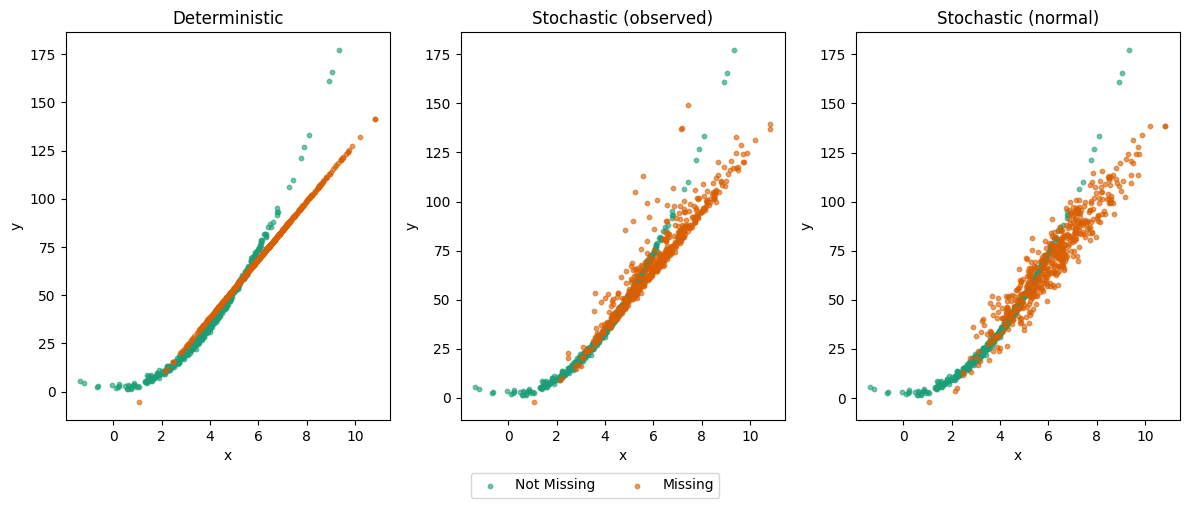

In [44]:
# Tworzenie wykresów
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

colors = {'Not Missing': '#1b9e77', 'Missing': '#d95f02'}  # Dark2 palette

for ax, y_col, title in zip(axes, ['y1', 'y2', 'y3'],
                             ['Deterministic', 'Stochastic (observed)', 'Stochastic (normal)']):
    for label, color in colors.items():
        mask = sim_data['any_missing'] == label
        ax.scatter(sim_data.loc[mask, 'x'], sim_data.loc[mask, y_col],
                   c=color, label=label, alpha=0.6, s=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# Wspólna legenda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Zapisanie wykresu
#plt.savefig('/mnt/user-data/outputs/fig-regimp.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
np.random.seed(2025)

n = 1000
x = np.random.normal(5, 2, n)
y = np.exp(2 + 2 * x) * np.exp(np.random.normal(0, 1, n))
pr = expit(5 - 1 * x)  # plogis(5 - 1*x)
R = np.random.binomial(1, pr, n)
y_miss = np.where(R == 1, y, np.nan)

sim_data = pd.DataFrame({
    'x': x,
    'y': y,
    'R': R,
    'y1': y_miss.copy(),
    'y2': y_miss.copy(),
    'y3': y_miss.copy()
})

sim_data['is_missing'] = sim_data['y1'].isna()
sim_data.head()

,x,y,R,y1,y2,y3,is_missing
0,4.815220,2.588739e+05,1,258873.864114,258873.864114,258873.864114,False
1,6.468571,7.655088e+06,0,NaN,NaN,NaN,True
2,2.122236,5.749381e+02,1,574.938122,574.938122,574.938122,False
3,3.673156,3.360470e+04,1,33604.703470,33604.703470,33604.703470,False
4,4.798544,7.333412e+04,1,73334.116097,73334.116097,73334.116097,False


In [46]:
mask_complete = ~sim_data['y1'].isna()
X_complete = sim_data.loc[mask_complete, 'x'].values.reshape(-1, 1)
y_complete = sim_data.loc[mask_complete, 'y1'].values
model = LinearRegression()
model.fit(X_complete, y_complete)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
mask_missing = sim_data['y1'].isna()
X_missing = sim_data.loc[mask_missing, 'x'].values.reshape(-1, 1)
y_pred = model.predict(X_missing)

# Obliczenie reszt dla kompletnych obserwacji
residuals_complete = y_complete - model.predict(X_complete)
residual_std = np.std(residuals_complete, ddof=1)

# 1. Imputacja deterministyczna (bez residuów)
sim_data.loc[mask_missing, 'y1'] = y_pred

# 2. Imputacja stochastyczna (residua z obserwowanych)
np.random.seed(2025)
sampled_residuals = np.random.choice(residuals_complete, size=mask_missing.sum(), replace=True)
sim_data.loc[mask_missing, 'y2'] = y_pred + sampled_residuals

# 3. Imputacja stochastyczna (residua z rozkładu normalnego)
np.random.seed(2025)
normal_residuals = np.random.normal(0, residual_std, mask_missing.sum())
sim_data.loc[mask_missing, 'y3'] = y_pred + normal_residuals
sim_data['any_missing'] = sim_data['is_missing'].map({True: 'Missing', False: 'Not Missing'})

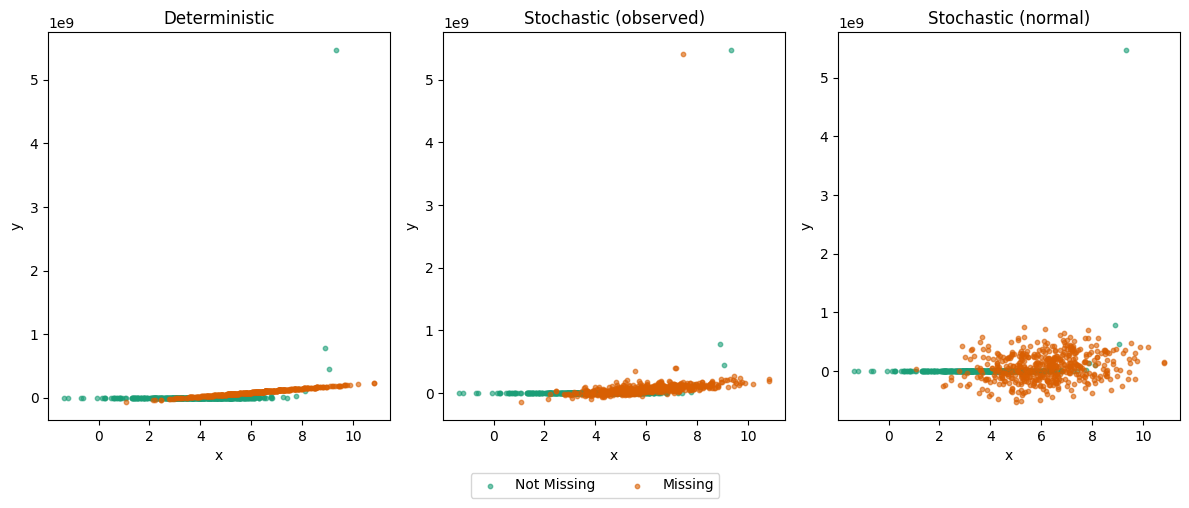

In [48]:
# Tworzenie wykresów
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

colors = {'Not Missing': '#1b9e77', 'Missing': '#d95f02'}  # Dark2 palette

for ax, y_col, title in zip(axes, ['y1', 'y2', 'y3'],
                             ['Deterministic', 'Stochastic (observed)', 'Stochastic (normal)']):
    for label, color in colors.items():
        mask = sim_data['any_missing'] == label
        ax.scatter(sim_data.loc[mask, 'x'], sim_data.loc[mask, y_col],
                   c=color, label=label, alpha=0.6, s=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)

# Wspólna legenda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Zapisanie wykresu
#plt.savefig('/mnt/user-data/outputs/fig-regimp.png', dpi=150, bbox_inches='tight')
plt.show()